m_k: [ 25  31  39  48  61  76  95 119 149 186 232]

Running scenario theta_a=0.1, theta_b=0.5
  simulation 20/100 for theta_a=0.1, theta_b=0.5
  simulation 40/100 for theta_a=0.1, theta_b=0.5
  simulation 60/100 for theta_a=0.1, theta_b=0.5
  simulation 80/100 for theta_a=0.1, theta_b=0.5
  simulation 100/100 for theta_a=0.1, theta_b=0.5

Running scenario theta_a=0.1, theta_b=0.75
  simulation 20/100 for theta_a=0.1, theta_b=0.75
  simulation 40/100 for theta_a=0.1, theta_b=0.75
  simulation 60/100 for theta_a=0.1, theta_b=0.75
  simulation 80/100 for theta_a=0.1, theta_b=0.75
  simulation 100/100 for theta_a=0.1, theta_b=0.75

Running scenario theta_a=0.1, theta_b=1.0
  simulation 20/100 for theta_a=0.1, theta_b=1.0
  simulation 40/100 for theta_a=0.1, theta_b=1.0
  simulation 60/100 for theta_a=0.1, theta_b=1.0
  simulation 80/100 for theta_a=0.1, theta_b=1.0
  simulation 100/100 for theta_a=0.1, theta_b=1.0

Running scenario theta_a=0.5, theta_b=0.1
  simulation 20/100 for theta_a=0

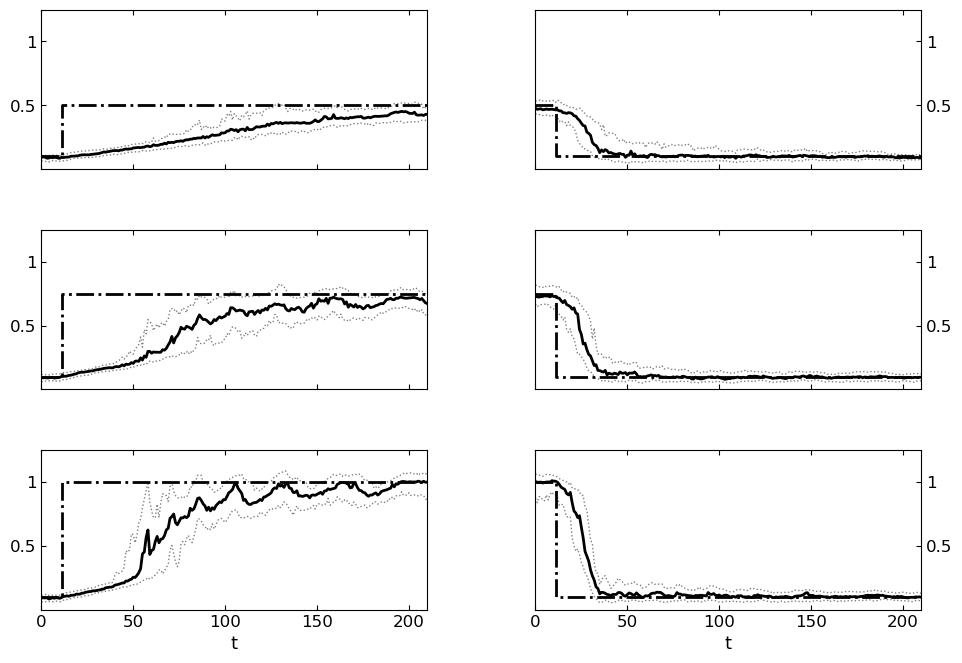

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# Settings
# =====================================================

N_SIM = 100
d = 6

m0 = 20
c = 1.25
K = 11
rho = 0.5

theta_low = 0.10
theta_levels = [0.50, 0.75, 1.00]

# Time range from slide:
# theta_t = theta_a for -390 <= t <= 10
# theta_t = theta_b for 10 < t <= 210
t_all = np.arange(-390, 211)
t_eval = np.arange(0, 211)

change_time = 10

# Geometric grid
k_values = np.arange(1, K + 1)
m_values = np.array([int(np.floor(m0 * c**k)) for k in k_values])

print("m_k:", m_values)

rng = np.random.default_rng(12345)

# LCP tuning parameter.
# Smaller -> reacts faster, noisier.
# Larger -> smoother, slower adaptation.
CRIT = 1.25


# =====================================================
# Clayton copula sampler
# =====================================================

def simulate_clayton_d(theta, n, d, rng):
    """
    Simulate n observations from d-dimensional Clayton copula.

    Marshall-Olkin representation:
        W ~ Gamma(1/theta, 1)
        E_j ~ Exp(1)
        U_j = (1 + E_j/W)^(-1/theta)
    """

    W = rng.gamma(shape=1.0 / theta, scale=1.0, size=(n, 1))
    E = rng.exponential(scale=1.0, size=(n, d))

    U = (1.0 + E / W) ** (-1.0 / theta)

    return U


def simulate_time_varying_clayton(theta_a, theta_b, t_all, change_time, d, rng):
    """
    Simulate observations from a time-varying Clayton copula:

        theta_t = theta_a, if t <= change_time
        theta_t = theta_b, if t > change_time
    """

    U = np.zeros((len(t_all), d))

    idx_a = np.where(t_all <= change_time)[0]
    idx_b = np.where(t_all > change_time)[0]

    U[idx_a] = simulate_clayton_d(theta_a, len(idx_a), d, rng)
    U[idx_b] = simulate_clayton_d(theta_b, len(idx_b), d, rng)

    return U


# =====================================================
# Fast dependence-to-theta calibration
# =====================================================

def average_pairwise_corr(U):
    """
    Average pairwise Pearson correlation across the d copula coordinates.
    Used as a fast monotone dependence proxy.
    """

    C = np.corrcoef(U, rowvar=False)

    idx = np.triu_indices_from(C, k=1)

    return np.nanmean(C[idx])


def build_corr_to_theta_calibration(theta_grid, n_calib=50000, d=6, seed=777):
    """
    Build interpolation map from average pairwise correlation to Clayton theta.
    This avoids doing MLE thousands of times.
    """

    local_rng = np.random.default_rng(seed)

    corr_grid = []

    for theta in theta_grid:
        U = simulate_clayton_d(theta, n_calib, d, local_rng)
        corr_grid.append(average_pairwise_corr(U))

    corr_grid = np.array(corr_grid)

    # Ensure monotonicity for interpolation stability
    order = np.argsort(corr_grid)

    return corr_grid[order], theta_grid[order]


theta_grid = np.linspace(0.02, 1.50, 80)
corr_grid, theta_grid_sorted = build_corr_to_theta_calibration(
    theta_grid=theta_grid,
    n_calib=50000,
    d=d,
    seed=777
)


def corr_to_theta(corr_value):
    """
    Convert average pairwise correlation to approximate Clayton theta.
    """

    corr_value = np.clip(corr_value, corr_grid[0], corr_grid[-1])

    return np.interp(corr_value, corr_grid, theta_grid_sorted)


# =====================================================
# Fast rolling interval correlation estimator
# =====================================================

def prepare_cumulative_moments(U):
    """
    Precompute cumulative sums and cumulative outer products.
    This makes interval correlation estimates fast.
    """

    N, d = U.shape

    cum_sum = np.zeros((N + 1, d))
    cum_outer = np.zeros((N + 1, d, d))

    for i in range(N):
        cum_sum[i + 1] = cum_sum[i] + U[i]
        cum_outer[i + 1] = cum_outer[i] + np.outer(U[i], U[i])

    return cum_sum, cum_outer


def avg_corr_interval(cum_sum, cum_outer, start, end):
    """
    Average pairwise correlation on interval [start, end),
    using cumulative moments.
    """

    n = end - start

    if n <= 2:
        return 0.0

    S = cum_sum[end] - cum_sum[start]
    Q = cum_outer[end] - cum_outer[start]

    mean = S / n

    cov = (Q - n * np.outer(mean, mean)) / max(n - 1, 1)

    var = np.diag(cov)
    var = np.maximum(var, 1e-12)

    std = np.sqrt(var)
    Corr = cov / np.outer(std, std)

    idx = np.triu_indices_from(Corr, k=1)

    return np.nanmean(Corr[idx])


def estimate_theta_interval(cum_sum, cum_outer, start, end):
    """
    Estimate Clayton theta on one interval.
    """

    corr_hat = avg_corr_interval(cum_sum, cum_outer, start, end)

    return corr_to_theta(corr_hat)


# =====================================================
# LCP-style adaptive estimator
# =====================================================

def lcp_estimate_path(U, t_all, t_eval, m_values, m0, crit):
    """
    Compute adaptive local estimates theta_hat_t.

    For each t0:
      1. compute estimates on nested intervals I_k = [t0 - m_k, t0]
      2. start with the shortest interval
      3. extend interval while candidate remains compatible
      4. return the estimate on the largest accepted interval
    """

    N, d = U.shape

    # Map time value to array index
    time_to_index = {t: i for i, t in enumerate(t_all)}

    cum_sum, cum_outer = prepare_cumulative_moments(U)

    theta_hat_path = np.zeros(len(t_eval))

    max_m = int(m_values[-1])

    for pos, t0 in enumerate(t_eval):

        end_idx = time_to_index[t0] + 1

        theta_candidates = []
        m_candidates = []

        # Candidate intervals ending at t0
        for m_k in m_values:

            start_idx = end_idx - m_k

            if start_idx < 0:
                continue

            theta_k = estimate_theta_interval(
                cum_sum=cum_sum,
                cum_outer=cum_outer,
                start=start_idx,
                end=end_idx
            )

            theta_candidates.append(theta_k)
            m_candidates.append(m_k)

        theta_candidates = np.array(theta_candidates)
        m_candidates = np.array(m_candidates)

        if len(theta_candidates) == 0:
            theta_hat_path[pos] = np.nan
            continue

        # Start with shortest interval
        accepted_idx = 0
        theta_accepted = theta_candidates[accepted_idx]
        m_accepted = m_candidates[accepted_idx]

        # Try extending to larger intervals
        for k in range(1, len(theta_candidates)):

            theta_candidate = theta_candidates[k]
            m_candidate = m_candidates[k]

            n_eff = (m_accepted * m_candidate) / (m_accepted + m_candidate)

            # Compatibility statistic.
            # This is a simple LCP-style test statistic.
            stat = (
                np.sqrt(n_eff)
                * abs(theta_candidate - theta_accepted)
                / (0.20 + theta_accepted)
            )

            if stat <= crit:
                accepted_idx = k
                theta_accepted = theta_candidate
                m_accepted = m_candidate
            else:
                break

        theta_hat_path[pos] = theta_accepted

    return theta_hat_path


# =====================================================
# Run simulations for one scenario
# =====================================================

def run_scenario(theta_a, theta_b, n_sim, rng):
    """
    Run repeated simulations for one pair (theta_a, theta_b).
    Returns all estimated theta paths.
    """

    estimates = np.zeros((n_sim, len(t_eval)))

    for s in range(n_sim):

        if (s + 1) % 20 == 0:
            print(
                f"  simulation {s + 1}/{n_sim} "
                f"for theta_a={theta_a}, theta_b={theta_b}"
            )

        U = simulate_time_varying_clayton(
            theta_a=theta_a,
            theta_b=theta_b,
            t_all=t_all,
            change_time=change_time,
            d=d,
            rng=rng
        )

        estimates[s] = lcp_estimate_path(
            U=U,
            t_all=t_all,
            t_eval=t_eval,
            m_values=m_values,
            m0=m0,
            crit=CRIT
        )

    return estimates


# =====================================================
# Define scenarios
# =====================================================

# Left column:
# theta_a = 0.10, theta_b = 0.50, 0.75, 1.00
left_scenarios = [
    (theta_low, 0.50),
    (theta_low, 0.75),
    (theta_low, 1.00),
]

# Right column:
# theta_b = 0.10, theta_a = 0.50, 0.75, 1.00
right_scenarios = [
    (0.50, theta_low),
    (0.75, theta_low),
    (1.00, theta_low),
]


# =====================================================
# Simulate all scenarios
# =====================================================

results = {}

for scenario in left_scenarios + right_scenarios:

    theta_a, theta_b = scenario

    print(f"\nRunning scenario theta_a={theta_a}, theta_b={theta_b}")

    estimates = run_scenario(
        theta_a=theta_a,
        theta_b=theta_b,
        n_sim=N_SIM,
        rng=rng
    )

    median = np.nanmedian(estimates, axis=0)
    q25 = np.nanquantile(estimates, 0.25, axis=0)
    q75 = np.nanquantile(estimates, 0.75, axis=0)

    true_theta = np.where(t_eval <= change_time, theta_a, theta_b)

    results[scenario] = {
        "median": median,
        "q25": q25,
        "q75": q75,
        "true": true_theta
    }


# =====================================================
# Plot figure similar to slide
# =====================================================

fig, axes = plt.subplots(
    3, 2,
    figsize=(10, 8),
    sharex=True,
    sharey=True
)

for row in range(3):

    # --------------------------
    # Left column
    # --------------------------

    theta_a, theta_b = left_scenarios[row]
    ax = axes[row, 0]

    res = results[(theta_a, theta_b)]

    ax.plot(
        t_eval,
        res["median"],
        color="black",
        linewidth=2.0
    )

    ax.plot(
        t_eval,
        res["q25"],
        color="gray",
        linewidth=1.0,
        linestyle=":"
    )

    ax.plot(
        t_eval,
        res["q75"],
        color="gray",
        linewidth=1.0,
        linestyle=":"
    )

    ax.step(
        t_eval,
        res["true"],
        where="post",
        color="black",
        linewidth=2.0,
        linestyle="-."
    )

    # --------------------------
    # Right column
    # --------------------------

    theta_a, theta_b = right_scenarios[row]
    ax = axes[row, 1]

    res = results[(theta_a, theta_b)]

    ax.plot(
        t_eval,
        res["median"],
        color="black",
        linewidth=2.0
    )

    ax.plot(
        t_eval,
        res["q25"],
        color="gray",
        linewidth=1.0,
        linestyle=":"
    )

    ax.plot(
        t_eval,
        res["q75"],
        color="gray",
        linewidth=1.0,
        linestyle=":"
    )

    ax.step(
        t_eval,
        res["true"],
        where="post",
        color="black",
        linewidth=2.0,
        linestyle="-."
    )


# =====================================================
# Axis formatting
# =====================================================

for ax in axes.flat:

    ax.set_xlim(0, 210)
    ax.set_ylim(0, 1.25)

    ax.set_xticks([0, 50, 100, 150, 200])
    ax.set_yticks([0.5, 1.0])
    ax.set_yticklabels(["0.5", "1"])

    ax.tick_params(
        direction="in",
        top=True,
        right=True,
        labelsize=12
    )

    for spine in ax.spines.values():
        spine.set_linewidth(0.8)

# =====================================================
# Axis labels: left column labels on left, right column labels on right
# =====================================================

# x-axis labels only on bottom row
for ax in axes[2, :]:
    ax.set_xlabel("t", fontsize=13)

# y-axis labels for left column
for ax in axes[:, 0]:
    ax.yaxis.set_label_position("left")
    ax.yaxis.tick_left()
    ax.tick_params(labelleft=True, labelright=False)

# y-axis labels for right column
for ax in axes[:, 1]:
    ax.yaxis.set_label_position("left")
    ax.yaxis.tick_right()
    ax.tick_params(labelleft=False, labelright=True)


# =====================================================
# Caption similar to slide
# =====================================================


plt.subplots_adjust(
    left=0.10,
    right=0.98,
    top=0.93,
    bottom=0.18,
    hspace=0.38,
    wspace=0.28
)

fig.savefig(
    "figure47_lcp_clayton.png",
    dpi=200,
    bbox_inches="tight", transparent=True 
)

plt.show()